<a href="https://colab.research.google.com/github/AhmedButtar7/AI-ML-internship-DevelopersHub/blob/main/Phase_2/Task_1/Developers_Hub_Phase_2_task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
!pip install streamlit --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 40.2 MB/s eta 0:00:00


In [ ]:
import transformers
import datasets
import sklearn
import streamlit

print(f"Transformers version: {transformers.__version__}")
print(f"Datasets version: {datasets.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print("✅ All packages installed successfully!")

Transformers version: 5.9.0
Datasets version: 5.0.0
Scikit-learn version: 1.6.1
✅ All packages installed successfully!


In [ ]:
# Install tensorflow_datasets
!pip install tensorflow tensorflow_datasets

import tensorflow_datasets as tfds
from datasets import Dataset, DatasetDict
import numpy as np

# Load AG News using tensorflow_datasets
print("Loading AG News dataset via TensorFlow Datasets...")
tfds_dataset = tfds.load('ag_news_subset', split=['train', 'test'], as_supervised=True)

# Convert to Hugging Face format
train_list = []
test_list = []

for text, label in tfds_dataset[0]:
    text_str = text.numpy().decode('utf-8')
    label_int = label.numpy()
    train_list.append({'text': text_str, 'label': label_int})

for text, label in tfds_dataset[1]:
    text_str = text.numpy().decode('utf-8')
    label_int = label.numpy()
    test_list.append({'text': text_str, 'label': label_int})

# Create datasets
train_dataset = Dataset.from_list(train_list)
test_dataset = Dataset.from_list(test_list)

dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

print(f"✅ Dataset loaded successfully!")
print(f"Training samples: {len(dataset['train']):,}")
print(f"Test samples: {len(dataset['test']):,}")

Loading AG News dataset via TensorFlow Datasets...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.FEP5D9_1.0.0/ag_news_subset-train.tfrecord-[0-9]…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.FEP5D9_1.0.0/ag_news_subset-test.tfrecord-[0-9][…

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.
✅ Dataset loaded successfully!
Training samples: 120,000
Test samples: 7,600


In [ ]:
# Importing all used libraries
import torch
import numpy as np
import pandas as pd
import tensorflow_datasets as tfds
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
#Load AG News dataset using TensorFlow Datasets
print("\n📥 Loading AG News dataset using TensorFlow Datasets...")
tfds_dataset = tfds.load('ag_news_subset', split=['train', 'test'], as_supervised=True)

# Convert to Hugging Face format
train_list = []
test_list = []

print("Converting training data...")
for text, label in tfds_dataset[0]:
    text_str = text.numpy().decode('utf-8')
    label_int = int(label.numpy())
    train_list.append({'text': text_str, 'label': label_int})

print("Converting test data...")
for text, label in tfds_dataset[1]:
    text_str = text.numpy().decode('utf-8')
    label_int = int(label.numpy())
    test_list.append({'text': text_str, 'label': label_int})


📥 Loading AG News dataset using TensorFlow Datasets...
Converting training data...
Converting test data...


In [ ]:
# Create datasets
train_dataset = Dataset.from_list(train_list)
test_dataset = Dataset.from_list(test_list)

dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

In [ ]:
# Display dataset information
print(f"\n✅ Dataset loaded successfully!")
print(f"📊 Dataset Statistics:")
print(f"  Training samples: {len(dataset['train']):,}")
print(f"  Test samples: {len(dataset['test']):,}")


✅ Dataset loaded successfully!
📊 Dataset Statistics:
  Training samples: 120,000
  Test samples: 7,600


In [ ]:
# Label mapping
label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

In [ ]:
# Show sample data
print(f"\n📝 Sample Training Data:")
print("="*60)
for i in range(5):
    sample = dataset['train'][i]
    print(f"Text: {sample['text'][:100]}...")
    print(f"Label: {sample['label']} ({label_names[sample['label']]})")
    print("-"*60)


📝 Sample Training Data:
Text: AMD #39;s new dual-core Opteron chip is designed mainly for corporate computing applications, includ...
Label: 3 (Sci/Tech)
------------------------------------------------------------
Text: Reuters - Major League Baseball\Monday announced a decision on the appeal filed by Chicago Cubs\pitc...
Label: 1 (Sports)
------------------------------------------------------------
Text: President Bush #39;s  quot;revenue-neutral quot; tax reform needs losers to balance its winners, and...
Label: 2 (Business)
------------------------------------------------------------
Text: Britain will run out of leading scientists unless science education is improved, says Professor Coli...
Label: 3 (Sci/Tech)
------------------------------------------------------------
Text: London, England (Sports Network) - England midfielder Steven Gerrard injured his groin late in Thurs...
Label: 1 (Sports)
------------------------------------------------------------


In [ ]:
# Check class distribution
train_labels = [sample['label'] for sample in dataset['train']]
label_counts = Counter(train_labels)

print(f"\n📊 Class Distribution:")
for label, count in label_counts.items():
    percentage = (count / len(train_labels)) * 100
    print(f"  {label_names[label]}: {count:,} ({percentage:.1f}%)")


📊 Class Distribution:
  Sci/Tech: 30,000 (25.0%)
  Sports: 30,000 (25.0%)
  Business: 30,000 (25.0%)
  World: 30,000 (25.0%)


In [ ]:
# Step 5: Tokenization
print("\n🔄 Tokenizing dataset...")
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256,
        return_tensors=None
    )

# Apply tokenization
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Remove original text column and rename label to labels
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Set format for PyTorch
tokenized_datasets.set_format("torch")

print(f"✅ Tokenization complete!")
print(f"  Training set columns: {tokenized_datasets['train'].column_names}")
print(f"  Input shape: {tokenized_datasets['train'][0]['input_ids'].shape}")




🔄 Tokenizing dataset...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

✅ Tokenization complete!
  Training set columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
  Input shape: torch.Size([256])


In [ ]:
# Step 6: Load Model
print("\n📊 Loading BERT model...")
num_labels = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
model = model.to(device)

print(f"Model loaded on: {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")


📊 Loading BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda
Number of parameters: 109,485,316


In [ ]:
# Step 7: Define Metrics Function
def compute_metrics(eval_pred):
    """Calculate evaluation metrics"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1,
    }

In [ ]:
# Step 8: Configure Training Arguments
print("\n⚙️ Configuring training...")
training_args = TrainingArguments(
    # Output and logging
    output_dir="./bert_news_checkpoints",
    logging_dir="./logs",
    run_name="bert-news-classifier",

    # Training hyperparameters
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,

    # Evaluation strategy
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # Logging and saving
    logging_steps=100,
    save_total_limit=2,
    report_to="none",

    # Performance optimizations
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,

    # Reproducibility
    seed=42,
)

print(f"✅ Training configured:")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  FP16: {training_args.fp16}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



⚙️ Configuring training...
✅ Training configured:
  Learning rate: 2e-05
  Batch size: 16
  Epochs: 3
  FP16: True


In [ ]:
# Step 9: Initialize Trainer and Train
print("\n" + "="*60)
print("🚀 Starting Training...")
print("="*60)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Start training
trainer.train()

print("\n" + "="*60)
print("✅ Training Completed!")
print("="*60)



🚀 Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.232706,0.194589,0.936184,0.936359
2,0.159369,0.215349,0.939605,0.939611
3,0.085928,0.252591,0.943553,0.943558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


✅ Training Completed!


In [ ]:
# Step 10: Evaluation
print("\n📊 Evaluating model on test set...")
eval_results = trainer.evaluate()

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
for metric_name, value in eval_results.items():
    if 'eval_' in metric_name:
        metric_display = metric_name.replace('eval_', '')
        print(f"{metric_display.capitalize()}: {value:.4f}")


📊 Evaluating model on test set...


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.085928,0.252591,3,0.943553,0.943558



EVALUATION RESULTS
Loss: 0.2526
Accuracy: 0.9436
F1: 0.9436



📈 Generating detailed classification report...



CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World       0.96      0.95      0.96      1900
      Sports       0.98      0.99      0.98      1900
    Business       0.92      0.91      0.91      1900
    Sci/Tech       0.92      0.92      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



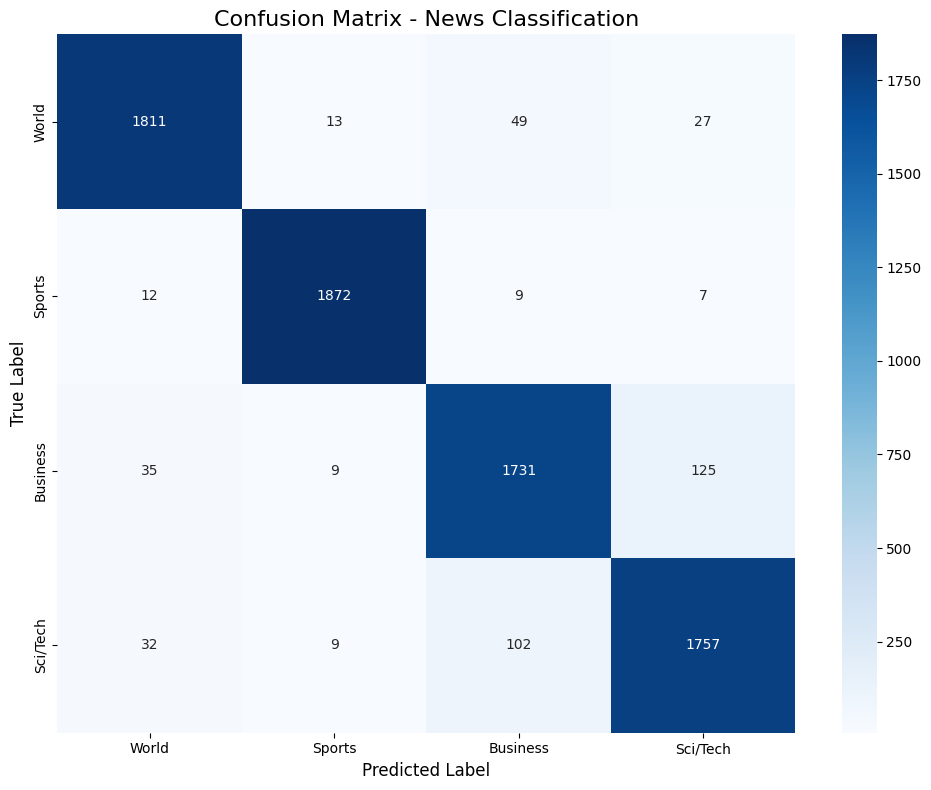


🔍 Testing with custom headlines...

📰 Headline: UN Security Council votes on new sanctions against North Korea
   Predicted: World (99.9%)

📰 Headline: Manchester City wins Premier League title on final day
   Predicted: World (76.2%)

📰 Headline: Apple stock hits all-time high after record quarterly earnings
   Predicted: Sci/Tech (99.3%)

📰 Headline: Scientists discover water on distant exoplanet
   Predicted: Sci/Tech (94.7%)

📰 Headline: Bitcoin crashes 20% as regulatory concerns mount
   Predicted: Sci/Tech (98.2%)

📰 Headline: Federer announces retirement after legendary career
   Predicted: World (96.7%)

📊 SUMMARY TABLE
                                                      headline predicted  confidence
UN Security Council votes on new sanctions against North Korea     World    0.999382
        Manchester City wins Premier League title on final day     World    0.762297
Apple stock hits all-time high after record quarterly earnings  Sci/Tech    0.992596
                Scienti

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to ./ag_news_classifier_final

Saved files:
  • tokenizer.json (0.68 MB)
  • tokenizer_config.json (0.00 MB)
  • model.safetensors (417.68 MB)
  • config.json (0.00 MB)
  • training_args.bin (0.01 MB)


In [ ]:
# Step 11: Detailed Classification Report
print("\n📈 Generating detailed classification report...")
predictions = trainer.predict(tokenized_datasets["test"])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Classification report
report = classification_report(true_labels, pred_labels, target_names=list(label_names.values()))
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(report)

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_names.values()),
            yticklabels=list(label_names.values()))
plt.title('Confusion Matrix - News Classification', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Step 12: Test with Custom Examples
print("\n🔍 Testing with custom headlines...")
test_headlines = [
    "UN Security Council votes on new sanctions against North Korea",  # World
    "Manchester City wins Premier League title on final day",         # Sports
    "Apple stock hits all-time high after record quarterly earnings", # Business
    "Scientists discover water on distant exoplanet",                 # Sci/Tech
    "Bitcoin crashes 20% as regulatory concerns mount",               # Business
    "Federer announces retirement after legendary career",            # Sports
]

model.eval()
results = []

for headline in test_headlines:
    # Tokenize
    inputs = tokenizer(headline, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred].item()

    results.append({
        'headline': headline,
        'predicted': label_names[pred],
        'confidence': confidence
    })

    # Display result
    print(f"\n📰 Headline: {headline}")
    print(f"   Predicted: {label_names[pred]} ({confidence:.1%})")

# Create summary DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("📊 SUMMARY TABLE")
print("="*60)
print(results_df.to_string(index=False))

# Step 13: Save Model
print("\n💾 Saving model...")
model_save_path = "./ag_news_classifier_final"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✅ Model saved to {model_save_path}")
print("\nSaved files:")
import os
for file in os.listdir(model_save_path):
    file_size = os.path.getsize(f"{model_save_path}/{file}") / (1024 * 1024)
    print(f"  • {file} ({file_size:.2f} MB)")


In [ ]:
# Step 14: Quick Test with Saved Model
print("\n🔄 Testing saved model...")
loaded_model = AutoModelForSequenceClassification.from_pretrained(model_save_path)
loaded_tokenizer = AutoTokenizer.from_pretrained(model_save_path)
loaded_model = loaded_model.to(device)

test_text = "NASA announces new mission to Mars"
inputs = loaded_tokenizer(test_text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = loaded_model(**inputs)
    pred = torch.argmax(outputs.logits, dim=-1).item()
print(f"Test: '{test_text}' → {label_names[pred]}")
print("✅ Model saved and reloaded successfully!")

print("\n🎉 All tasks completed successfully!")
print("📊 Model trained and ready for deployment")


🔄 Testing saved model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test: 'NASA announces new mission to Mars' → Sci/Tech
✅ Model saved and reloaded successfully!

🎉 All tasks completed successfully!
📊 Model trained and ready for deployment
